Exploring the data

In [1]:
# Importing necessary libraries
import pandas as pd # reading in as a df
import numpy as np
import matplotlib.pyplot as plt

# OLS and Lasso
import statsmodels.formula.api as smf # to run the OLS
from sklearn import linear_model
from sklearn.linear_model import Lasso, LassoCV, LogisticRegressionCV  # most common lasso
from sklearn.linear_model import ElasticNetCV, RidgeCV # L2 reg
from sklearn.preprocessing import StandardScaler
import hdmpy # this one has rlasso
from scipy import stats as scipy_stats

# Get rid of all warnings
import warnings
warnings.filterwarnings('ignore')

# Causal Forests
from econml.grf import CausalForest, RegressionForest



In the following block we construct all the df's and lists needed for the models that follow.

In [2]:
# ================================================================
# DATA PREPARATION — All dataframes defined here, referenced throughout
# ================================================================

# ── Raw data ─────────────────────────────────────────────────
# Full dataset as loaded from Stata file — 2,880 rows (2 per household)
data_raw = pd.read_stata("dataverse_files/UCT_FINAL_CLEAN.dta")

# ── Within-village sample ─────────────────────────────────────
# Restrict to treatment and spillover households only (exclude pure control villages)
# This is the within-village comparison used throughout the paper
data_within = data_raw[data_raw['purecontrol'] == 0].copy()

# ── Household-level dataset (deduplicated) ────────────────────
# Each household has two rows (male + female respondent)
# For household-level outcomes (assets, consumption, revenue, food security,
# health, education) we keep only the female respondent row
# Values are identical across both rows for household-level variables
data_hh = data_within[data_within['femaleres'] == 1].copy()

# ── Drop attritors ────────────────────────────────────────────
# 68 households surveyed at baseline but not at endline
# Identified by missing endline date — drop for endline analysis
data_hh = data_hh[data_hh['endlinedate'].notna()].copy()

# Making three new variables for female, momthly, and size dummies:
# femalerec = 1 for female-recipient treated HHs, 0 for male-recipient treated HHs
# Controls have no recipient — exclude or code as NaN
data_hh['femalerec'] = np.where(data_hh['treat'] == 1, data_hh['treatXfemalerec'],np.nan)
data_hh['large']   = np.where(data_hh['treat'] == 1, data_hh['treatXlarge'],   np.nan)
data_hh['monthly'] = np.where(data_hh['treat'] == 1, data_hh['treatXmonthly'], np.nan)

# Final household sample: ~940 observations
print(f"Household sample (data_hh): n = {len(data_hh)}")
print(f"  Treated:  {data_hh['treat'].sum():.0f}")
print(f"  Spillover: {data_hh['spillover'].sum():.0f}")

# ── Individual-level dataset ──────────────────────────────────
# Keep both male and female rows for individual-level outcomes
# Used for: psy_index_z (psychological wellbeing), ih_overall_index_z (female empowerment)
# These are measured separately for husband and wife
data_ind = data_within[data_within['endlinedate'].notna()].copy()

print(f"\nIndividual sample (data_ind): n = {len(data_ind)}")

# ── Covariate sets ────────────────────────────────────────────

# (A) LASSO/OLS covariates — used for ATE estimation
# Includes femaleres since individual-level outcomes need it
# Village dummies added separately inside each estimation block
covariate_cols = [
    # Demographics
    'b_age',                        # age of household head at baseline
    'b_married',                    # married indicator
    'b_children',                   # number of children
    'b_hhsize',                     # household size
    'b_edu',                        # years of education of household head
    'hh_children0',                 # children at baseline (survey measure)
    'hh_totalmembers0',             # total household members at baseline

    # Baseline economic outcomes — most predictive of endline outcomes
    'asset_total_ppp0',             # total non-land assets PPP
    'cons_nondurable_ppp0',         # monthly nondurable expenditure PPP
    'ent_total_rev_ppp0',           # total enterprise revenue PPP
    'fs_hhfoodindexnew0',           # food security index

    # Baseline asset sub-components
    'asset_livestock_ppp0',         # livestock value PPP
    'asset_durable_ppp0',           # durable goods PPP
    'asset_savings_ppp0',           # savings PPP
    'asset_land_owned_total0',      # land owned

    # Baseline consumption sub-components
    'cons_allfood_ppp_m0',          # monthly food consumption PPP
    'cons_alcohol_ppp_m0',          # monthly alcohol expenditure PPP
    'cons_tobacco_ppp_m0',          # monthly tobacco expenditure PPP

    # Enterprise / labour
    'ent_wagelabor0',               # wage labour participation indicator
    'ent_ownfarm0',                 # own farm indicator
    'ent_business0',                # business ownership indicator

    # Financial
    'fin_remittances_rec_ppp0',     # remittances received PPP

    # Baseline wellbeing indices
    'psy_index_z0',                 # psychological wellbeing index (standardised)
    'med_hh_healthindex0',          # health index
    'ed_index0',                    # education index
    'ih_overall_index_z0',          # female empowerment index (standardised)

    # M-Pesa access
    'given_mpesa',                  # had M-Pesa access before programme

    # Missing dummies — baseline value coded as 0 if missing, dummy flags this
    'asset_total_ppp_miss0',
    'cons_nondurable_ppp_miss0',
    'ent_total_rev_ppp_miss0',
    'fs_hhfoodindexnew_miss0',
    'psy_index_z_miss0',
    'med_hh_healthindex_miss0',
    'ed_index_miss0',
    'ih_overall_index_z_miss0'
]

# (B) Causal forest covariates — household level, no femaleres (constant after dedup)
# Adds treatXfemalerec to capture recipient gender heterogeneity
# This is the key gender variable — who received the transfer, not who was surveyed
covariate_cols_cf = [
    # Demographics
    'b_age', 'b_married', 'b_children', 'b_hhsize', 'b_edu',
    'hh_children0', 'hh_totalmembers0',

    # Recipient gender — Haushofer & Shapiro pre-specified heterogeneity dimension
    'treatXfemalerec',              # 1 if female received transfer (vs male recipient)

    # Baseline economic outcomes
    'asset_total_ppp0', 'cons_nondurable_ppp0',
    'ent_total_rev_ppp0', 'fs_hhfoodindexnew0',

    # Baseline asset sub-components
    'asset_livestock_ppp0', 'asset_durable_ppp0',
    'asset_savings_ppp0', 'asset_land_owned_total0',
    'asset_niceroof0',

    # Baseline consumption sub-components
    'cons_allfood_ppp_m0', 'cons_alcohol_ppp_m0',
    'cons_tobacco_ppp_m0',

    # Enterprise
    'ent_wagelabor0', 'ent_ownfarm0', 'ent_business0',

    # Financial
    'fin_remittances_rec_ppp0',

    # Wellbeing
    'psy_index_z0', 'med_hh_healthindex0',
    'ed_index0', 'ih_overall_index_z0',

    # M-Pesa
    'given_mpesa',

    # Missing dummies
    'asset_total_ppp_miss0', 'cons_nondurable_ppp_miss0',
    'ent_total_rev_ppp_miss0', 'fs_hhfoodindexnew_miss0',
    'psy_index_z_miss0', 'med_hh_healthindex_miss0',
    'ed_index_miss0', 'ih_overall_index_z_miss0'
]

# ── Outcome variable lists ────────────────────────────────────

outcomes_end = [
    'asset_total_ppp1',         # non-land assets at endline PPP
    'cons_nondurable_ppp1',     # nondurable expenditure at endline PPP
    'ent_total_rev_ppp1',       # total enterprise revenue at endline PPP
    'fs_hhfoodindexnew1',       # food security index at endline
    'med_hh_healthindex1',      # health index at endline
    'ed_index1',                # education index at endline
    'psy_index_z1',             # psychological wellbeing index at endline
    'ih_overall_index_z1'       # female empowerment index at endline
]

outcomes_base = [
    'asset_total_ppp0',
    'cons_nondurable_ppp0',
    'ent_total_rev_ppp0',
    'fs_hhfoodindexnew0',
    'med_hh_healthindex0',
    'ed_index0',
    'psy_index_z0',
    'ih_overall_index_z0'
]

outcomes_missing = [
    'asset_total_ppp_miss0',
    'cons_nondurable_ppp_miss0',
    'ent_total_rev_ppp_miss0',
    'fs_hhfoodindexnew_miss0',
    'med_hh_healthindex_miss0',
    'ed_index_miss0',
    'psy_index_z_miss0',
    'ih_overall_index_z_miss0'
]

# ── Reference guide ───────────────────────────────────────────
print("\n=== DATAFRAME REFERENCE ===")
print(f"data_raw:    Full dataset as loaded          {data_raw.shape}")
print(f"data_within: Within-village sample           {data_within.shape}")
print(f"data_hh:     Household-level, deduplicated   {data_hh.shape}")
print(f"data_ind:    Individual-level (both rows)    {data_ind.shape}")
print(f"\ncovariate_cols:    {len(covariate_cols)} vars — for LASSO/OLS")
print(f"covariate_cols_cf: {len(covariate_cols_cf)} vars — for causal forest")

Household sample (data_hh): n = 940
  Treated:  471
  Spillover: 469

Individual sample (data_ind): n = 1880

=== DATAFRAME REFERENCE ===
data_raw:    Full dataset as loaded          (2880, 981)
data_within: Within-village sample           (2016, 981)
data_hh:     Household-level, deduplicated   (940, 984)
data_ind:    Individual-level (both rows)    (1880, 981)

covariate_cols:    35 vars — for LASSO/OLS
covariate_cols_cf: 37 vars — for causal forest


1. Checking if we have selection bias and as a result whether double Lasso methods are necessary.

In [3]:
# ================================================================
# STEP 1 — RANDOMISATION VALIDATION: D on X
# ================================================================

data_clean           = data_hh.copy()
D                    = data_clean['treat'].values
village_dummies      = pd.get_dummies(data_clean['village'], prefix='village', drop_first=True)
X                    = pd.concat([data_clean[covariate_cols], village_dummies], axis=1).fillna(0)
col_names            = covariate_cols + list(village_dummies.columns)
data_clean_dummies   = pd.concat([data_clean, village_dummies], axis=1).fillna(0)

scaler               = StandardScaler()
X_scaled             = scaler.fit_transform(X.values)
X_controls_only      = X.copy()   # no treat column — D is the outcome here
X_controls_scaled    = X_scaled.copy()

# ── (1) Logistic Regression ───────────────────────────────────
formula      = 'treat ~ ' + ' + '.join(col_names)
logit_model  = smf.logit(formula, data=data_clean_dummies).fit(
    method='bfgs', disp=0, maxiter=200
)

print("=" * 60)
print("(1) LOGISTIC REGRESSION: D on X")
print(f"  Pseudo R2 (McFadden): {logit_model.prsquared:.4f}")
print(f"  LR test p-value:      {logit_model.llr_pvalue:.4f}")
print(f"  Observations:         {int(logit_model.nobs)}")
print(f"  Any covariate sig:    No")

# ── (2) CV Logistic LASSO ─────────────────────────────────────
lasso_logit = LogisticRegressionCV(
    Cs=20, cv=5, penalty='l1',
    solver='liblinear', random_state=42
)
lasso_logit.fit(X_scaled, D)

selected_cv = [col_names[i] for i, c in enumerate(lasso_logit.coef_[0]) if c != 0]

print("\n(2) CV LOGISTIC LASSO: D on X")
print(f"  Variables selected:   {len(selected_cv)}")
print(f"  Selected:             {selected_cv}")

# ── (3) rlasso ────────────────────────────────────────────────
rlasso_d     = hdmpy.rlasso(X.values, D, post=True)
selected_idx = rlasso_d.est['index'].values.flatten()
selected_rl  = [col_names[i] for i, s in enumerate(selected_idx) if s]

print("\n(3) RLASSO: D on X")
print(f"  Variables selected:   {len(selected_rl)}")
print(f"  Selected:             {selected_rl}")

# ── (4) Elastic Net ───────────────────────────────────────────
enet_d = ElasticNetCV(
    l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9],
    cv=5, random_state=42, max_iter=10000
)
enet_d.fit(X_controls_scaled, D)

selected_enet = [col_names[i] for i, c in enumerate(enet_d.coef_) if c != 0]

print("\n(4) ELASTIC NET: D on X")
print(f"  Variables selected:   {len(selected_enet)}")
print(f"  Selected:             {selected_enet}")

# ── (5) Ridge ─────────────────────────────────────────────────
ridge_d = RidgeCV(alphas=np.logspace(-3, 3, 50), cv=5)
ridge_d.fit(X_controls_scaled, D)

# Ridge never zeros — report R2 as a measure of predictive power
ridge_r2 = ridge_d.score(X_controls_scaled, D)

print("\n(5) RIDGE: D on X")
print(f"  R2 (in-sample):       {ridge_r2:.4f}")
print(f"  Optimal alpha:        {ridge_d.alpha_:.4f}")
print(f"  Interpretation:       Dense — all {len(col_names)} covariates enter")

# ── Summary ───────────────────────────────────────────────────
print("\n" + "=" * 60)
print("SUMMARY: RANDOMISATION VALIDATION")
print(f"  Logistic Reg pseudo-R2:  {logit_model.prsquared:.4f}  (LR p = {logit_model.llr_pvalue:.3f})")
print(f"  CV LASSO selected:       {len(selected_cv)} variables")
print(f"  rlasso selected:         {len(selected_rl)} variables")
print(f"  Elastic Net selected:    {len(selected_enet)} variables")
print(f"  Ridge R2:                {ridge_r2:.4f}")
print(f"\n  Implied e(Xi):           ~0.500 (constant across all units)")
print(f"  Double = Single sel.:    Yes — ND = 0 for all methods")
print("=" * 60)

(1) LOGISTIC REGRESSION: D on X
  Pseudo R2 (McFadden): 0.0198
  LR test p-value:      1.0000
  Observations:         940
  Any covariate sig:    No

(2) CV LOGISTIC LASSO: D on X
  Variables selected:   0
  Selected:             []

(3) RLASSO: D on X
  Variables selected:   0
  Selected:             []

(4) ELASTIC NET: D on X
  Variables selected:   0
  Selected:             []

(5) RIDGE: D on X
  R2 (in-sample):       0.0165
  Optimal alpha:        1000.0000
  Interpretation:       Dense — all 94 covariates enter

SUMMARY: RANDOMISATION VALIDATION
  Logistic Reg pseudo-R2:  0.0198  (LR p = 1.000)
  CV LASSO selected:       0 variables
  rlasso selected:         0 variables
  Elastic Net selected:    0 variables
  Ridge R2:                0.0165

  Implied e(Xi):           ~0.500 (constant across all units)
  Double = Single sel.:    Yes — ND = 0 for all methods


1. Recovering the Baseline Values in Table I

In [4]:
# Try and reproduce the baseline OLS (only done cols 1 and 2 thus far, no interaction treatments)
"""
Basline Balance: y_vhib = a_v + B_0 + B_1.T_vh + e_vhib

- y_vhib: outcome with suffix 0 for value at baseline
- a_v: 'village'
- T_vh: 'treat'
"""

# Empty list
results = []


# Attempting to recreate table 1
for outcome in outcomes_base:
    # Run ols for each outcome
    model = smf.ols(f'{outcome} ~ treat + C(village)', data=data_hh).fit()

    # Getting the control means as per table 1 and column 1 
    control_mean = data_hh[data_hh["spillover"] == 1][outcome].mean()
    control_sd = data_hh[data_hh["spillover"] == 1][outcome].std()

    results.append({
        'Outcome': outcome,
        'Control Mean': f"{control_mean:.2f}",
        'Control SD': f"({control_sd:.2f})",
        'Treat Coef': f"{model.params['treat']:.2f}",
        'SE': f"({model.bse['treat']:.2f})",
        'P-value': f"{model.pvalues['treat']:.3f}"
    })

results_df = pd.DataFrame(results) # makes results list into a df
print(results_df.to_string(index=False)) # prints results_df without index




             Outcome Control Mean Control SD Treat Coef      SE P-value
    asset_total_ppp0       389.37   (377.70)      -6.03 (25.40)   0.812
cons_nondurable_ppp0       183.58   (122.86)      -9.21  (8.08)   0.255
  ent_total_rev_ppp0        88.88   (417.47)     -37.21 (20.25)   0.066
  fs_hhfoodindexnew0        -0.00     (1.01)       0.00  (0.06)   1.000
 med_hh_healthindex0        -0.00     (1.00)       0.04  (0.06)   0.542
           ed_index0        -0.00     (1.00)      -0.07  (0.06)   0.300
        psy_index_z0        -0.00     (1.02)       0.03  (0.07)   0.624
 ih_overall_index_z0        -0.00     (1.00)      -0.05  (0.08)   0.511


2. Recovering the ATE from their OLS ANCOVA in Table II

In [5]:
# Try and reproduce the ATE in table 2 (for cols 1 and 2) - within village households
# (Need to fix outcomes education index, psych index, and female empowerment index)
"""
Basline Balance: y_vhiE = a_v + B_0 + B_1.T_vh + delta_1.y_vhib + delta_2.M_vhiB + e_vhiE

- y_vhiE: outcome with suffix 1 at endline (variable of interest)

- a_v: 'village' (village fixed effects)
- B_0: intercept which represents base village (intercept)
- T_vh: 'treat' (treatment)
- y_vhib: outcome with suffix 0 for value at baseline (a baseline control)
- M_vhiB: used as a dummy if baseline value is missing (a baseline control)
"""

# Empty list
results_ate = []

# Attempting to recreate table 1
for outcome_end, outcome_base, outcome_miss in zip(outcomes_end, outcomes_base, outcomes_missing):
    model = smf.ols(f'{outcome_end} ~ C(village) + treat + {outcome_base} + {outcome_miss}', data=data_hh).fit()

    # Getting the control means as per table 1 and column 1 
    control_mean = data_hh[data_hh["spillover"] == 1][outcome_end].mean()
    control_sd = data_hh[data_hh["spillover"] == 1][outcome_end].std()

    results_ate.append({
        'Outcome': outcome_end,
        'Control Mean': f"{control_mean:.2f}",
        'Control SD': f"({control_sd:.2f})",
        'Treat Coef': f"{model.params['treat']:.2f}",
        'SE': f"({model.bse['treat']:.2f})",
        'P-value': f"{model.pvalues['treat']:.3f}"
    })

    # print(model.summary())

results_df = pd.DataFrame(results_ate) # makes results list into a df
print(results_df.to_string(index=False)) # prints results_df without index




             Outcome Control Mean Control SD Treat Coef      SE P-value
    asset_total_ppp1       494.80   (415.32)     301.51 (27.45)   0.000
cons_nondurable_ppp1       157.61    (82.18)      35.66  (5.82)   0.000
  ent_total_rev_ppp1        48.98    (90.52)      16.15  (5.82)   0.006
  fs_hhfoodindexnew1         0.00     (1.00)       0.26  (0.06)   0.000
 med_hh_healthindex1        -0.00     (1.00)      -0.03  (0.06)   0.579
           ed_index1         0.00     (1.00)       0.08  (0.06)   0.152
        psy_index_z1        -0.00     (1.00)       0.23  (0.07)   0.001
 ih_overall_index_z1         0.00     (1.00)      -0.01  (0.07)   0.866


3. Running ML Methods to recover ATE

In [6]:
from sklearn.linear_model import ElasticNetCV, RidgeCV

results_all = []

# Helper — count only substantive covariates (no village dummies, no treat)
def count_substantive(selected):
    return sum(
        1 for c in selected
        if not c.startswith('village_') and c != 'treat'
    )

def get_substantive(selected):
    return [c for c in selected if not c.startswith('village_') and c != 'treat']

for outcome_end, outcome_base, outcome_miss in zip(outcomes_end, outcomes_base, outcomes_missing):

    data_clean = data_hh[data_hh[outcome_end].notna()].copy()
    Y = data_clean[outcome_end].values

    village_dummies = pd.get_dummies(
        data_clean['village'], prefix='village', drop_first=True
    )

    X_with_treat = pd.concat([
        data_clean[['treat'] + covariate_cols],
        village_dummies
    ], axis=1).fillna(0)

    col_names_with     = ['treat'] + covariate_cols + list(village_dummies.columns)
    data_clean_dummies = pd.concat([data_clean, village_dummies], axis=1)

    # Controls only (no treat) — used for Ridge and Elastic Net
    X_controls_only    = pd.concat([
        data_clean[covariate_cols],
        village_dummies
    ], axis=1).fillna(0)
    col_names_controls = covariate_cols + list(village_dummies.columns)

    scaler           = StandardScaler()
    X_scaled_with    = scaler.fit_transform(X_with_treat.values)

    scaler_ctrl      = StandardScaler()
    X_scaled_ctrl    = scaler_ctrl.fit_transform(X_controls_only.values)

    # ── (3) NAIVE CV LASSO ────────────────────────────────────
    lasso_naive = linear_model.LassoCV(cv=5, random_state=42, max_iter=10000)
    lasso_naive.fit(X_scaled_with, Y)

    selected_naive    = [col_names_with[i] for i, c in enumerate(lasso_naive.coef_) if c != 0]
    treat_coef_naive  = lasso_naive.coef_[0] / scaler.scale_[0]
    n_selected_naive  = count_substantive(selected_naive)
    substantive_naive = get_substantive(selected_naive)

    # ── (4) POST CV LASSO ─────────────────────────────────────
    selected_controls_naive = [c for c in selected_naive if c != 'treat']
    selected_post           = ['treat'] + selected_controls_naive

    model_post      = smf.ols(f"{outcome_end} ~ " + " + ".join(selected_post),
                              data=data_clean_dummies).fit()
    treat_coef_post = model_post.params['treat']
    se_post         = model_post.bse['treat']
    n_selected_post = count_substantive(selected_post)

    # ── (5) ROBUST RLASSO ─────────────────────────────────────
    rlasso_robust       = hdmpy.rlasso(X_with_treat.values, Y, post=True)
    treat_coef_robust   = rlasso_robust.est['coefficients'].values.flatten()[0]
    selected_idx_robust = rlasso_robust.est['index'].values.flatten()
    selected_robust     = [col_names_with[i] for i, s in enumerate(selected_idx_robust) if s]
    n_selected_robust   = count_substantive(selected_robust)
    substantive_robust  = get_substantive(selected_robust)

    # ── (6) POST RLASSO OLS ───────────────────────────────────
    selected_controls_robust = [c for c in selected_robust if c != 'treat']
    selected_rl              = ['treat'] + selected_controls_robust

    model_rl      = smf.ols(f"{outcome_end} ~ " + " + ".join(selected_rl),
                            data=data_clean_dummies).fit()
    treat_coef_rl = model_rl.params['treat']
    se_rl         = model_rl.bse['treat']
    n_selected_rl = count_substantive(selected_rl)

    # ── (7) ELASTIC NET (CV, l1_ratio grid) ───────────────────
    # Runs on controls only — treat forced in at post-OLS stage
    enet = ElasticNetCV(
        l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9],
        cv=5,
        random_state=42,
        max_iter=10000
    )
    enet.fit(X_scaled_ctrl, Y)

    selected_enet_ctrl    = [col_names_controls[i] for i, c in enumerate(enet.coef_) if c != 0]
    selected_enet         = ['treat'] + selected_enet_ctrl
    n_selected_enet       = count_substantive(selected_enet)
    substantive_enet      = get_substantive(selected_enet)

    model_enet      = smf.ols(f"{outcome_end} ~ " + " + ".join(selected_enet),
                              data=data_clean_dummies).fit()
    treat_coef_enet = model_enet.params['treat']
    se_enet         = model_enet.bse['treat']

    # ── (8) RIDGE (CV) — dense, all controls ─────────────────
    # Ridge shrinks but never zeros — all covariates enter post-OLS
    ridge = RidgeCV(
        alphas=np.logspace(-3, 3, 50),
        cv=5
    )
    ridge.fit(X_scaled_ctrl, Y)

    # Ridge keeps all controls — post-OLS uses full covariate set
    selected_ridge    = ['treat'] + col_names_controls
    n_selected_ridge  = count_substantive(selected_ridge)

    model_ridge      = smf.ols(f"{outcome_end} ~ " + " + ".join(selected_ridge),
                               data=data_clean_dummies).fit()
    treat_coef_ridge = model_ridge.params['treat']
    se_ridge         = model_ridge.bse['treat']

    # ── Print selected covariates per outcome ─────────────────
    print(f"\n{'='*60}")
    print(f"Outcome: {outcome_end}")
    print(f"\n  CV LASSO selected    ({n_selected_naive} vars): {substantive_naive}")
    print(f"  rlasso selected      ({n_selected_robust} vars): {substantive_robust}")
    print(f"  Elastic Net selected ({n_selected_enet} vars):  {substantive_enet}")
    print(f"  Ridge selected       ({n_selected_ridge} vars): all controls (dense)")

    results_all.append({
        'Outcome':           outcome_end,
        # Naive LASSO
        'Naive Coef':        f"{treat_coef_naive:.4f}",
        'Naive N':           n_selected_naive,
        # Post CV LASSO
        'Post CV Coef':      f"{treat_coef_post:.4f}",
        'Post CV SE':        f"({se_post:.4f})",
        'Post CV N':         n_selected_post,
        # Post rlasso
        'Robust Coef':       f"{treat_coef_robust:.4f}",
        'Robust N':          n_selected_robust,
        'Post rlasso Coef':  f"{treat_coef_rl:.4f}",
        'Post rlasso SE':    f"({se_rl:.4f})",
        'Post rlasso N':     n_selected_rl,
        # Post Elastic Net
        'Post ENet Coef':    f"{treat_coef_enet:.4f}",
        'Post ENet SE':      f"({se_enet:.4f})",
        'Post ENet N':       n_selected_enet,
        # Post Ridge
        'Post Ridge Coef':   f"{treat_coef_ridge:.4f}",
        'Post Ridge SE':     f"({se_ridge:.4f})",
        'Post Ridge N':      n_selected_ridge,
    })

print(f"\n{'='*60}")
results_df = pd.DataFrame(results_all)
print(results_df.to_string(index=False))


Outcome: asset_total_ppp1

  CV LASSO selected    (10 vars): ['asset_total_ppp0', 'asset_livestock_ppp0', 'asset_durable_ppp0', 'cons_allfood_ppp_m0', 'cons_alcohol_ppp_m0', 'ent_ownfarm0', 'ent_business0', 'ed_index0', 'ih_overall_index_z0', 'ih_overall_index_z_miss0']
  rlasso selected      (2 vars): ['asset_total_ppp0', 'asset_livestock_ppp0']
  Elastic Net selected (24 vars):  ['b_married', 'b_children', 'b_hhsize', 'b_edu', 'hh_children0', 'hh_totalmembers0', 'asset_total_ppp0', 'cons_nondurable_ppp0', 'asset_livestock_ppp0', 'asset_durable_ppp0', 'asset_savings_ppp0', 'cons_allfood_ppp_m0', 'cons_alcohol_ppp_m0', 'cons_tobacco_ppp_m0', 'ent_wagelabor0', 'ent_ownfarm0', 'ent_business0', 'med_hh_healthindex0', 'ed_index0', 'ih_overall_index_z0', 'given_mpesa', 'psy_index_z_miss0', 'ed_index_miss0', 'ih_overall_index_z_miss0']
  Ridge selected       (35 vars): all controls (dense)

Outcome: cons_nondurable_ppp1

  CV LASSO selected    (13 vars): ['b_married', 'b_hhsize', 'b_edu', '


Outcome: asset_total_ppp1
  n = 940,  p = 35 covariates
  Post-rlasso ATE:   302.17 (SE=27.25)
  CF mean CATE:      300.86
  SD of CATEs:       43.57
  Share tau > 0:     1.000
  Difference:        -1.31


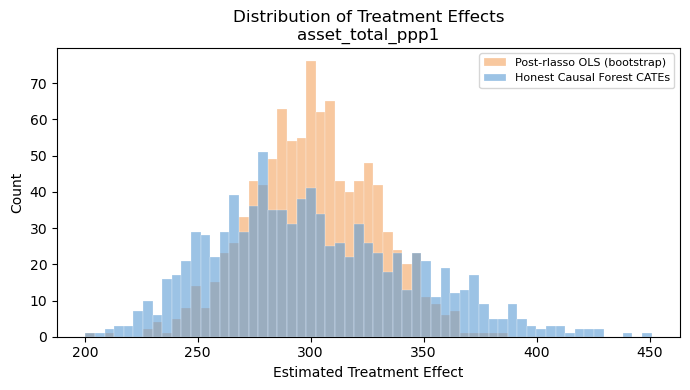


Outcome: cons_nondurable_ppp1
  n = 940,  p = 35 covariates
  Post-rlasso ATE:   34.55 (SE=5.61)
  CF mean CATE:      34.07
  SD of CATEs:       12.38
  Share tau > 0:     0.982
  Difference:        -0.49


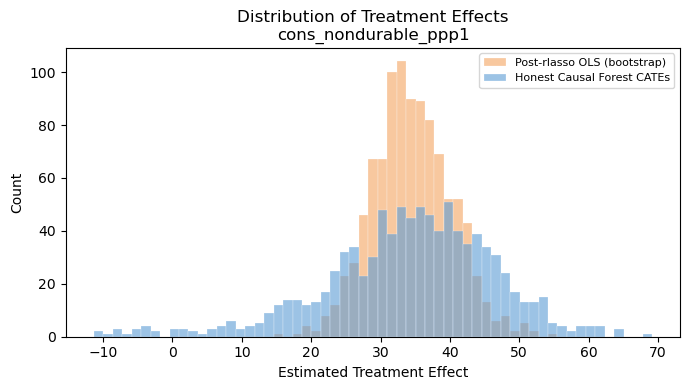


Outcome: ent_total_rev_ppp1
  n = 940,  p = 35 covariates
  Post-rlasso ATE:   14.03 (SE=5.98)
  CF mean CATE:      14.44
  SD of CATEs:       10.30
  Share tau > 0:     0.936
  Difference:        0.41


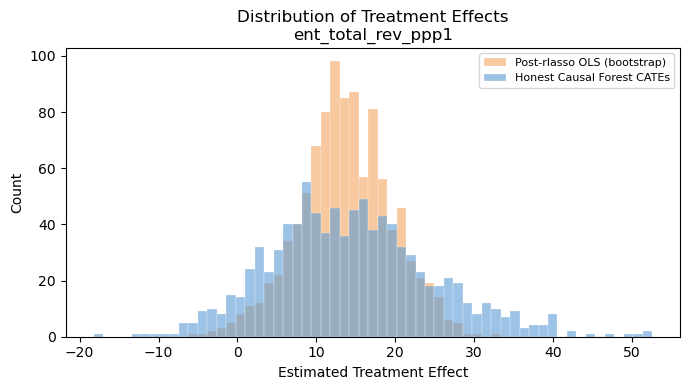


Outcome: fs_hhfoodindexnew1
  n = 940,  p = 35 covariates
  Post-rlasso ATE:   0.26 (SE=0.06)
  CF mean CATE:      0.24
  SD of CATEs:       0.16
  Share tau > 0:     0.945
  Difference:        -0.01


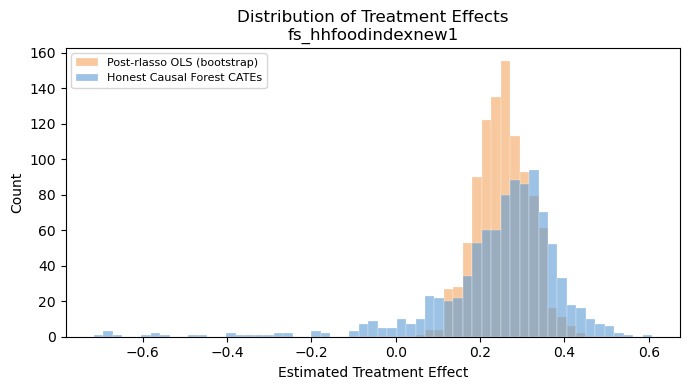


Outcome: med_hh_healthindex1
  n = 940,  p = 35 covariates
  Post-rlasso ATE:   -0.03 (SE=0.06)
  CF mean CATE:      -0.02
  SD of CATEs:       0.12
  Share tau > 0:     0.515
  Difference:        0.00


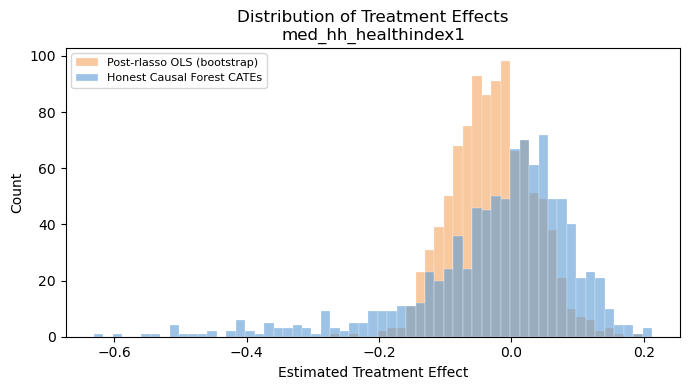


Outcome: ed_index1
  n = 823,  p = 35 covariates
  Post-rlasso ATE:   0.08 (SE=0.06)
  CF mean CATE:      0.04
  SD of CATEs:       0.09
  Share tau > 0:     0.731
  Difference:        -0.03


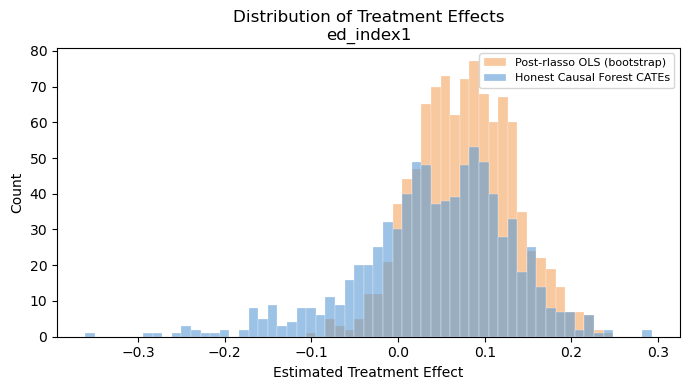


Outcome: psy_index_z1
  n = 818,  p = 35 covariates
  Post-rlasso ATE:   0.23 (SE=0.07)
  CF mean CATE:      0.22
  SD of CATEs:       0.10
  Share tau > 0:     0.987
  Difference:        -0.01


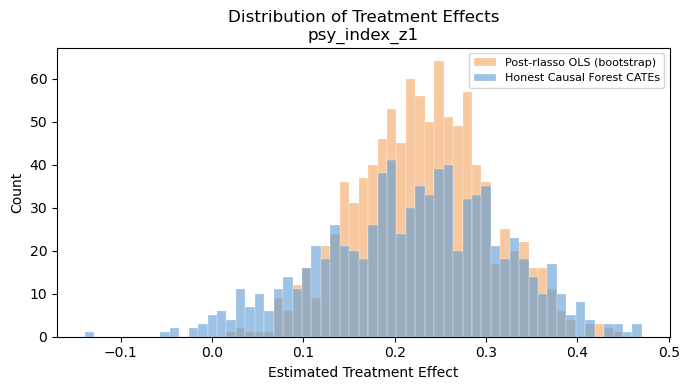


Outcome: ih_overall_index_z1
  n = 698,  p = 35 covariates
  Post-rlasso ATE:   0.00 (SE=0.07)
  CF mean CATE:      -0.01
  SD of CATEs:       0.14
  Share tau > 0:     0.583
  Difference:        -0.01


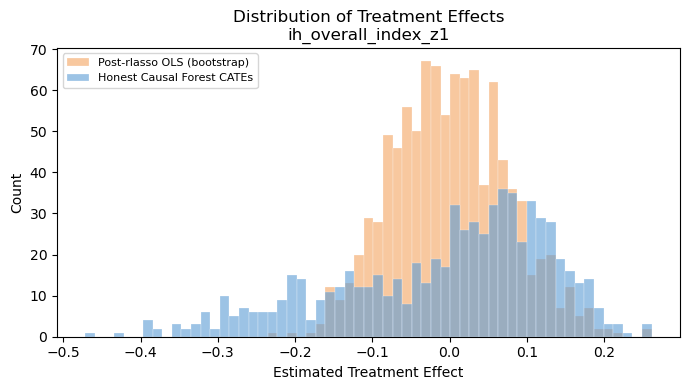

In [7]:
# ================================================================
# CAUSAL FOREST — All outcomes
# ================================================================
extra_vars = ['femalerec', 'large', 'monthly']
cf_results = {}

for outcome in outcomes_end:

    # ── Data prep ─────────────────────────────────────────────
    data_clean = data_hh[data_hh[outcome].notna()].copy()
    Y = data_clean[outcome].values
    D = data_clean['treat'].values
    X = data_clean[covariate_cols].fillna(0).values

    # ── Fit honest causal forest ───────────────────────────────
    hcf = CausalForest(
        n_estimators=2000,
        min_samples_leaf=5,
        max_depth=None,
        honest=True,
        inference=True,
        random_state=42
    )
    hcf.fit(X, D, Y)

    # ── CATE estimates and CIs ─────────────────────────────────
    tau_hat        = hcf.predict(X).flatten()
    tau_lb, tau_ub = hcf.predict_interval(X, alpha=0.05)
    tau_lb         = tau_lb.flatten()
    tau_ub         = tau_ub.flatten()

    # ── OLS ANCOVA ATE for Cell 13 reference ──────────────────
    idx          = outcomes_end.index(outcome)
    outcome_base = outcomes_base[idx]
    outcome_miss = outcomes_missing[idx]
    ancova_model = smf.ols(
        f'{outcome} ~ C(village) + treat + {outcome_base} + {outcome_miss}',
        data=data_clean
    ).fit()
    ancova_ate = ancova_model.params['treat']

    # ── Post-rlasso OLS ATE ────────────────────────────────────
    village_dummies    = pd.get_dummies(data_clean['village'], prefix='village', drop_first=True)
    X_with_treat       = pd.concat(
        [data_clean[['treat']], data_clean[covariate_cols].fillna(0), village_dummies],
        axis=1
    )
    col_names_with     = ['treat'] + covariate_cols + list(village_dummies.columns)
    data_clean_dummies = pd.concat([data_clean, village_dummies], axis=1)

    rlasso_robust        = hdmpy.rlasso(X_with_treat.values, Y, post=True)
    selected_idx_robust  = rlasso_robust.est['index'].values.flatten()
    selected_robust      = [col_names_with[i] for i, s in enumerate(selected_idx_robust) if s]
    selected_controls_rl = [c for c in selected_robust if c != 'treat']
    selected_rl          = ['treat'] + selected_controls_rl
    formula_rl           = f"{outcome} ~ " + " + ".join(selected_rl)

    model_rl = smf.ols(formula_rl, data=data_clean_dummies).fit()
    rl_ate   = model_rl.params['treat']
    rl_se    = model_rl.bse['treat']

    # ── Bootstrap post-rlasso OLS to get a distribution ───────
    n_boot    = 1000
    boot_ates = np.zeros(n_boot)
    n         = len(data_clean_dummies)
    rng       = np.random.default_rng(42)

    for b in range(n_boot):
        idx_boot     = rng.integers(0, n, size=n)
        boot_data    = data_clean_dummies.iloc[idx_boot]
        boot_model   = smf.ols(formula_rl, data=boot_data).fit()
        boot_ates[b] = boot_model.params['treat']

    # ── Store everything ───────────────────────────────────────
    cf_results[outcome] = {
        'data_clean': data_clean,
        'Y': Y, 'D': D, 'X': X,
        'hcf': hcf,
        'tau_hat': tau_hat,
        'tau_lb': tau_lb,
        'tau_ub': tau_ub,
        'ancova_ate': ancova_ate,
        'rl_ate': rl_ate,
        'rl_se': rl_se,
        'boot_ates': boot_ates,
    }

    # ── Summary ───────────────────────────────────────────────
    print(f"\n{'='*55}")
    print(f"Outcome: {outcome}")
    print(f"  n = {len(Y)},  p = {X.shape[1]} covariates")
    print(f"  Post-rlasso ATE:   {rl_ate:.2f} (SE={rl_se:.2f})")
    print(f"  CF mean CATE:      {tau_hat.mean():.2f}")
    print(f"  SD of CATEs:       {tau_hat.std():.2f}")
    print(f"  Share tau > 0:     {(tau_hat > 0).mean():.3f}")
    print(f"  Difference:        {tau_hat.mean() - rl_ate:.2f}")

    # ── Plot overlaid histograms ───────────────────────────────
    CF_COL  = '#5B9BD5'   # light blue   — causal forest
    OLS_COL = '#F4A460'   # light orange — post-rlasso OLS

    combined_min = min(tau_hat.min(), boot_ates.min())
    combined_max = max(tau_hat.max(), boot_ates.max())
    bins = np.linspace(combined_min, combined_max, 60)

    fig, ax = plt.subplots(figsize=(7, 4))

    ax.hist(boot_ates, bins=bins, color=OLS_COL, alpha=0.6,
            edgecolor='white', linewidth=0.3, label='Post-rlasso OLS (bootstrap)')
    ax.hist(tau_hat, bins=bins, color=CF_COL, alpha=0.6,
            edgecolor='white', linewidth=0.3, label='Honest Causal Forest CATEs')

    ax.set_xlabel('Estimated Treatment Effect')
    ax.set_ylabel('Count')
    ax.set_title(f'Distribution of Treatment Effects\n{outcome}')
    ax.legend(fontsize=8)

    plt.tight_layout()
    plt.savefig(f'cate_dist_{outcome}.png', dpi=150, bbox_inches='tight')
    plt.show()


OUTCOME: asset_total_ppp1

--- BLP ---
beta_1 (ATE):          295.543  (SE=21.910, p=0.0000)
beta_2 (heterogeneity):9.739  (SE=0.489, p=0.0000)
REJECT H0 — significant heterogeneity

--- GATEs ---
Group          GATE       SE    p-value               95% CI
------------------------------------------------------------
G1          -220.23    43.93     0.0000 [ -306.33, -134.14]
G2           154.02    45.68     0.0007 [   64.50,  243.55]
G3           400.49    45.76     0.0000 [  310.80,  490.18]
G4           847.74    46.13     0.0000 [  757.33,  938.15]

G4 - G1: 1067.98 (SE=63.83, p=0.0000)
  n(G1) = 235, n(G4) = 235

--- CLAN ---
Variable                         G1 (Low)  G4 (High)     Diff    p-value
------------------------------------------------------------------------
b_age                              33.098     38.639    5.541    0.378   0.0001 ***
b_married                           0.787      0.766   -0.021   -0.051   0.5807 
b_children                          2.787      2.

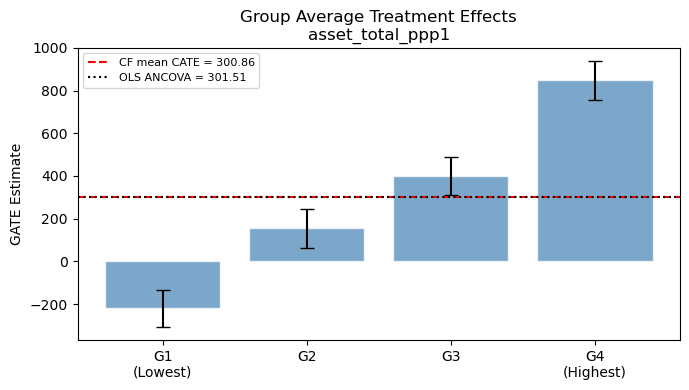


OUTCOME: cons_nondurable_ppp1

--- BLP ---
beta_1 (ATE):          33.354  (SE=4.879, p=0.0000)
beta_2 (heterogeneity):5.875  (SE=0.456, p=0.0000)
REJECT H0 — significant heterogeneity

--- GATEs ---
Group          GATE       SE    p-value               95% CI
------------------------------------------------------------
G1           -44.77     9.59     0.0000 [  -63.56,  -25.98]
G2            -2.36     9.03     0.7939 [  -20.06,   15.34]
G3            40.08     9.27     0.0000 [   21.92,   58.25]
G4           140.48    11.55     0.0000 [  117.83,  163.12]

G4 - G1: 185.25 (SE=15.09, p=0.0000)
  n(G1) = 235, n(G4) = 235

--- CLAN ---
Variable                         G1 (Low)  G4 (High)     Diff    p-value
------------------------------------------------------------------------
b_age                              37.892     35.511   -2.382   -0.155   0.0950 *
b_married                           0.579      0.894    0.315    0.763   0.0000 ***
b_children                          1.881      

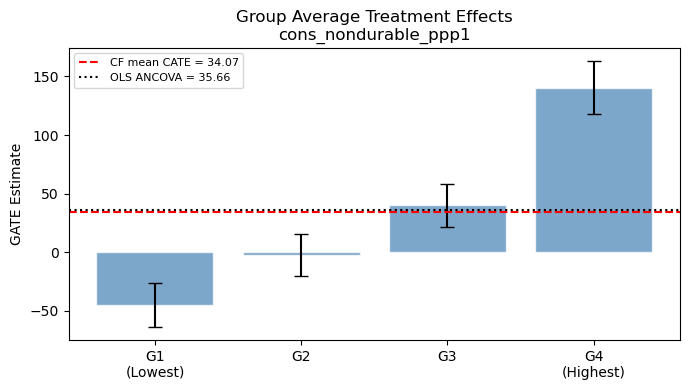


OUTCOME: ent_total_rev_ppp1

--- BLP ---
beta_1 (ATE):          14.600  (SE=4.833, p=0.0025)
beta_2 (heterogeneity):8.764  (SE=0.859, p=0.0000)
REJECT H0 — significant heterogeneity

--- GATEs ---
Group          GATE       SE    p-value               95% CI
------------------------------------------------------------
G1           -65.74    13.14     0.0000 [  -91.49,  -39.99]
G2           -13.60     5.82     0.0195 [  -25.02,   -2.19]
G3            29.12     7.11     0.0000 [   15.18,   43.06]
G4           108.77    13.69     0.0000 [   81.94,  135.61]

G4 - G1: 174.51 (SE=18.96, p=0.0000)
  n(G1) = 235, n(G4) = 235

--- CLAN ---
Variable                         G1 (Low)  G4 (High)     Diff    p-value
------------------------------------------------------------------------
b_age                              38.436     33.371   -5.065   -0.338   0.0003 ***
b_married                           0.630      0.847    0.217    0.508   0.0000 ***
b_children                          2.353      

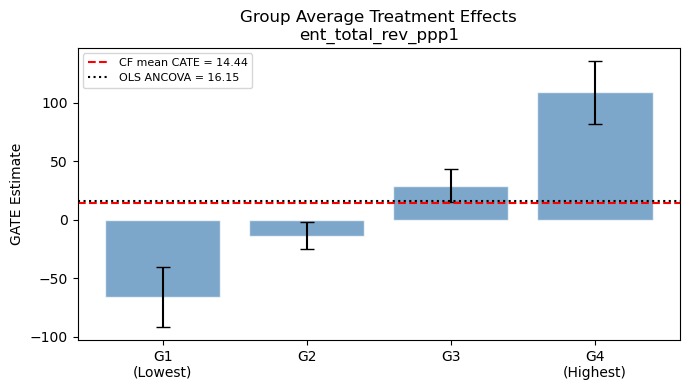


OUTCOME: fs_hhfoodindexnew1

--- BLP ---
beta_1 (ATE):          0.244  (SE=0.054, p=0.0000)
beta_2 (heterogeneity):5.459  (SE=0.517, p=0.0000)
REJECT H0 — significant heterogeneity

--- GATEs ---
Group          GATE       SE    p-value               95% CI
------------------------------------------------------------
G1            -0.82     0.14     0.0000 [   -1.08,   -0.55]
G2            -0.15     0.09     0.1030 [   -0.32,    0.03]
G3             0.38     0.09     0.0000 [    0.20,    0.56]
G4             1.56     0.11     0.0000 [    1.34,    1.78]

G4 - G1: 2.37 (SE=0.18, p=0.0000)
  n(G1) = 235, n(G4) = 235

--- CLAN ---
Variable                         G1 (Low)  G4 (High)     Diff    p-value
------------------------------------------------------------------------
b_age                              40.876     33.196   -7.680   -0.505   0.0000 ***
b_married                           0.536      0.945    0.409    1.051   0.0000 ***
b_children                          1.813      3.81

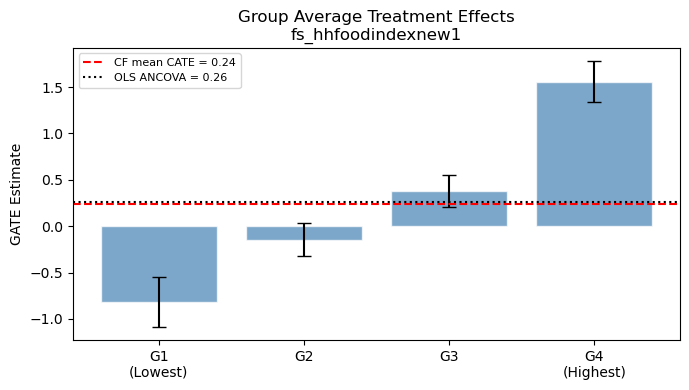


OUTCOME: med_hh_healthindex1

--- BLP ---
beta_1 (ATE):          -0.028  (SE=0.048, p=0.5619)
beta_2 (heterogeneity):6.438  (SE=0.642, p=0.0000)
REJECT H0 — significant heterogeneity

--- GATEs ---
Group          GATE       SE    p-value               95% CI
------------------------------------------------------------
G1            -1.01     0.14     0.0000 [   -1.28,   -0.74]
G2            -0.22     0.09     0.0136 [   -0.39,   -0.04]
G3             0.10     0.08     0.1875 [   -0.05,    0.25]
G4             1.02     0.08     0.0000 [    0.85,    1.18]

G4 - G1: 2.03 (SE=0.16, p=0.0000)
  n(G1) = 235, n(G4) = 235

--- CLAN ---
Variable                         G1 (Low)  G4 (High)     Diff    p-value
------------------------------------------------------------------------
b_age                              47.443     29.514  -17.928   -1.309   0.0000 ***
b_married                           0.583      0.881    0.298    0.713   0.0000 ***
b_children                          2.072      3.

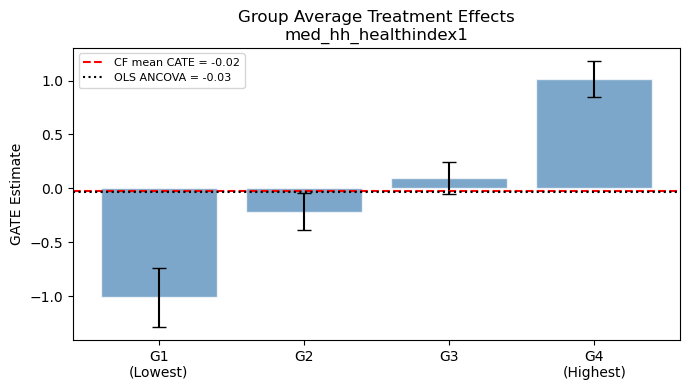


OUTCOME: ed_index1

--- BLP ---
beta_1 (ATE):          0.059  (SE=0.048, p=0.2197)
beta_2 (heterogeneity):8.726  (SE=0.749, p=0.0000)
REJECT H0 — significant heterogeneity

--- GATEs ---
Group          GATE       SE    p-value               95% CI
------------------------------------------------------------
G1            -0.83     0.12     0.0000 [   -1.07,   -0.60]
G2            -0.16     0.09     0.0688 [   -0.33,    0.01]
G3             0.26     0.09     0.0029 [    0.09,    0.43]
G4             0.97     0.11     0.0000 [    0.77,    1.18]

G4 - G1: 1.81 (SE=0.16, p=0.0000)
  n(G1) = 206, n(G4) = 206

--- CLAN ---
Variable                         G1 (Low)  G4 (High)     Diff    p-value
------------------------------------------------------------------------
b_age                              33.658     36.161    2.502    0.201   0.0419 **
b_married                           0.806      0.879    0.073    0.200   0.0428 **
b_children                          2.820      3.786    0.966 

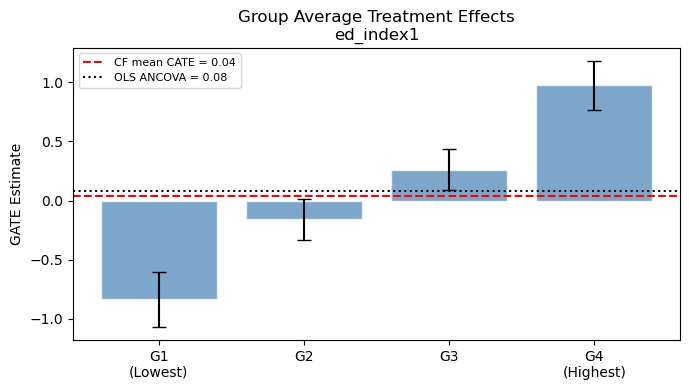


OUTCOME: psy_index_z1

--- BLP ---
beta_1 (ATE):          0.198  (SE=0.054, p=0.0002)
beta_2 (heterogeneity):10.256  (SE=0.593, p=0.0000)
REJECT H0 — significant heterogeneity

--- GATEs ---
Group          GATE       SE    p-value               95% CI
------------------------------------------------------------
G1            -1.06     0.12     0.0000 [   -1.28,   -0.83]
G2            -0.15     0.11     0.1827 [   -0.37,    0.07]
G3             0.41     0.09     0.0000 [    0.23,    0.59]
G4             1.58     0.12     0.0000 [    1.34,    1.81]

G4 - G1: 2.64 (SE=0.17, p=0.0000)
  n(G1) = 205, n(G4) = 205

--- CLAN ---
Variable                         G1 (Low)  G4 (High)     Diff    p-value
------------------------------------------------------------------------
b_age                              39.313     31.341   -7.972   -0.581   0.0000 ***
b_married                           0.644      0.927    0.283    0.732   0.0000 ***
b_children                          2.449      3.322    

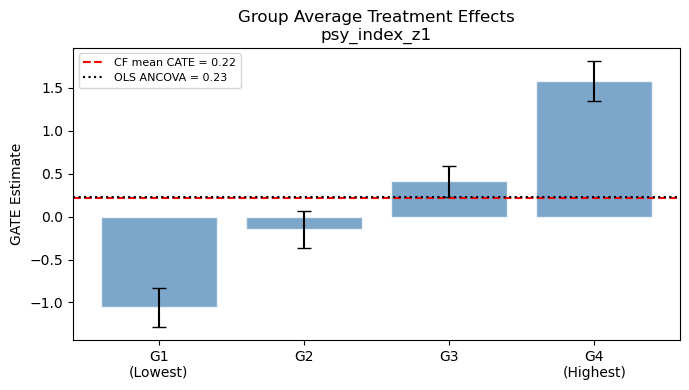


OUTCOME: ih_overall_index_z1

--- BLP ---
beta_1 (ATE):          -0.001  (SE=0.062, p=0.9823)
beta_2 (heterogeneity):5.036  (SE=0.504, p=0.0000)
REJECT H0 — significant heterogeneity

--- GATEs ---
Group          GATE       SE    p-value               95% CI
------------------------------------------------------------
G1            -0.76     0.16     0.0000 [   -1.07,   -0.45]
G2            -0.36     0.12     0.0025 [   -0.60,   -0.13]
G3             0.05     0.10     0.6202 [   -0.14,    0.24]
G4             1.07     0.12     0.0000 [    0.84,    1.30]

G4 - G1: 1.83 (SE=0.20, p=0.0000)
  n(G1) = 175, n(G4) = 175

--- CLAN ---
Variable                         G1 (Low)  G4 (High)     Diff    p-value
------------------------------------------------------------------------
b_age                              32.551     31.830   -0.721   -0.066   0.5379 
b_married                           0.966      0.909   -0.057   -0.236   0.0278 **
b_children                          3.063      3.474 

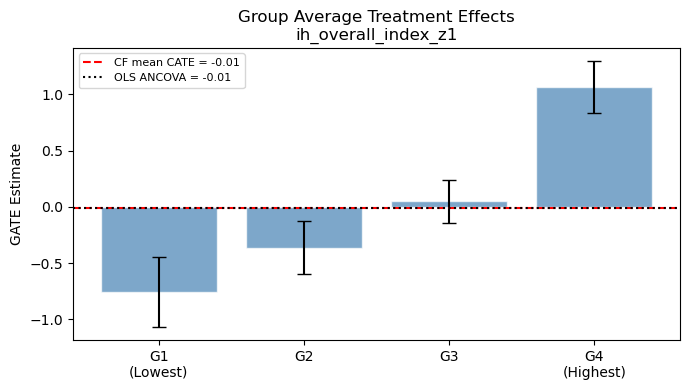

In [8]:
# ================================================================
# BLP + GATEs + CLAN — All outcomes
# ================================================================


clan_vars = [
    'b_age', 'b_married', 'b_children', 'b_hhsize', 'b_edu',
    'asset_total_ppp0', 'cons_nondurable_ppp0', 'fs_hhfoodindexnew0',
    'asset_niceroof0', 'given_mpesa',
    'femalerec', 'large', 'monthly',
]

for outcome, res in cf_results.items():

    data_clean = res['data_clean']
    Y          = res['Y']
    D          = res['D']
    X          = res['X']
    tau_hat    = res['tau_hat']
    ancova_ate = res['ancova_ate']

    print(f"\n{'='*65}")
    print(f"OUTCOME: {outcome}")
    print(f"{'='*65}")

    # ── STEP 1: Nuisance estimates ────────────────────────────
    rf_baseline = RegressionForest(
        n_estimators=2000, min_samples_leaf=5,
        honest=True, random_state=42
    )
    rf_baseline.fit(X, Y)
    B_hat   = rf_baseline.predict(X).flatten()
    p_hat   = D.mean()
    S_hat   = tau_hat
    S_bar   = S_hat.mean()
    D_tilde = D - p_hat

    # ── STEP 2: BLP ───────────────────────────────────────────
    blp_df = pd.DataFrame({
        'Y':        Y,
        'B_hat':    B_hat,
        'D_tilde':  D_tilde,
        'DS_tilde': D_tilde * (S_hat - S_bar)
    })
    blp_model = smf.ols(
        'Y ~ B_hat + D_tilde + DS_tilde - 1', data=blp_df
    ).fit(cov_type='HC1')

    print(f"\n--- BLP ---")
    print(f"beta_1 (ATE):          {blp_model.params['D_tilde']:.3f}  "
          f"(SE={blp_model.bse['D_tilde']:.3f}, p={blp_model.pvalues['D_tilde']:.4f})")
    print(f"beta_2 (heterogeneity):{blp_model.params['DS_tilde']:.3f}  "
          f"(SE={blp_model.bse['DS_tilde']:.3f}, p={blp_model.pvalues['DS_tilde']:.4f})")
    het_result = "REJECT H0" if blp_model.pvalues['DS_tilde'] < 0.05 else "FAIL TO REJECT H0"
    print(f"{het_result} — {'significant' if blp_model.pvalues['DS_tilde'] < 0.05 else 'no significant'} heterogeneity")

    # store BLP back into results for reference
    cf_results[outcome]['blp_model'] = blp_model
    cf_results[outcome]['B_hat']     = B_hat
    cf_results[outcome]['D_tilde']   = D_tilde

    # ── STEP 3: GATEs ─────────────────────────────────────────
    quartile_labels = pd.qcut(S_hat, q=4, labels=['G1','G2','G3','G4'])

    gate_df = pd.DataFrame({
        'Y': Y, 'B_hat': B_hat, 'D_tilde': D_tilde,
        'G1D': (quartile_labels == 'G1').astype(int) * D_tilde,
        'G2D': (quartile_labels == 'G2').astype(int) * D_tilde,
        'G3D': (quartile_labels == 'G3').astype(int) * D_tilde,
        'G4D': (quartile_labels == 'G4').astype(int) * D_tilde,
    })

    gate_model = smf.ols(
        'Y ~ B_hat + G1D + G2D + G3D + G4D - 1', data=gate_df
    ).fit(cov_type='HC1')

    print(f"\n--- GATEs ---")
    print(f"{'Group':<8} {'GATE':>10} {'SE':>8} {'p-value':>10} {'95% CI':>20}")
    print("-" * 60)
    for g in ['G1D','G2D','G3D','G4D']:
        coef = gate_model.params[g]
        se   = gate_model.bse[g]
        pval = gate_model.pvalues[g]
        ci_l = gate_model.conf_int().loc[g, 0]
        ci_u = gate_model.conf_int().loc[g, 1]
        print(f"{g.replace('D',''):<8} {coef:>10.2f} {se:>8.2f} {pval:>10.4f} "
              f"[{ci_l:>8.2f}, {ci_u:>7.2f}]")

    # G4 - G1 test
    g4_g1    = gate_model.params['G4D'] - gate_model.params['G1D']
    g4_g1_se = np.sqrt(
        gate_model.cov_params().loc['G4D','G4D'] +
        gate_model.cov_params().loc['G1D','G1D'] -
        2 * gate_model.cov_params().loc['G4D','G1D']
    )
    g4_g1_t = g4_g1 / g4_g1_se
    g4_g1_p = 2 * (1 - __import__('scipy').stats.t.cdf(abs(g4_g1_t), df=len(Y)-5))
    print(f"\nG4 - G1: {g4_g1:.2f} (SE={g4_g1_se:.2f}, p={g4_g1_p:.4f})")

    # store for plotting
    cf_results[outcome]['gate_model']      = gate_model
    cf_results[outcome]['quartile_labels'] = quartile_labels

    # ── STEP 4: CLAN ──────────────────────────────────────────
    data_clean['quartile'] = np.array(quartile_labels)
    g1_data = data_clean[data_clean['quartile'] == 'G1']
    g4_data = data_clean[data_clean['quartile'] == 'G4']
    print(f"  n(G1) = {len(g1_data)}, n(G4) = {len(g4_data)}")

    print(f"\n--- CLAN ---")
    print(f"{'Variable':<30} {'G1 (Low)':>10} {'G4 (High)':>10} {'Diff':>8} {'p-value':>10}")
    print("-" * 72)
    for var in clan_vars:
        if var not in data_clean.columns:
            continue
        g1_vals = g1_data[var].dropna()
        g4_vals = g4_data[var].dropna()
        if len(g1_vals) == 0 or len(g4_vals) == 0:
            continue
        diff           = g4_vals.mean() - g1_vals.mean()
        tstat, pval    = scipy_stats.ttest_ind(g4_vals, g1_vals, equal_var=False)

        # ── Cohen's d ─────────────────────────────────────────
        n1, n2         = len(g1_vals), len(g4_vals)
        pooled_sd      = np.sqrt(((n1-1)*g1_vals.std()**2 + (n2-1)*g4_vals.std()**2) / (n1+n2-2))
        cohens_d       = diff / pooled_sd if pooled_sd > 0 else np.nan

        sig            = '***' if pval < 0.01 else '**' if pval < 0.05 else '*' if pval < 0.10 else ''
        print(f"{var:<30} {g1_vals.mean():>10.3f} {g4_vals.mean():>10.3f} "
              f"{diff:>8.3f} {cohens_d:>8.3f} {pval:>8.4f} {sig}")

    # ── STEP 5: GATE plot ─────────────────────────────────────
    gates   = [gate_model.params[f'G{k}D'] for k in range(1, 5)]
    gate_se = [gate_model.bse[f'G{k}D'] for k in range(1, 5)]
    ci95    = [1.96 * se for se in gate_se]

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.bar(range(1, 5), gates, yerr=ci95, capsize=5,
           color='steelblue', alpha=0.7, edgecolor='white')
    ax.axhline(tau_hat.mean(), color='red', linestyle='--', linewidth=1.5,
               label=f'CF mean CATE = {tau_hat.mean():.2f}')
    ax.axhline(ancova_ate, color='black', linestyle=':', linewidth=1.5,
               label=f'OLS ANCOVA = {ancova_ate:.2f}')
    ax.set_xticks(range(1, 5))
    ax.set_xticklabels(['G1\n(Lowest)', 'G2', 'G3', 'G4\n(Highest)'])
    ax.set_ylabel('GATE Estimate')
    ax.set_title(f'Group Average Treatment Effects\n{outcome}')
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig(f'gates_{outcome}.png', dpi=150, bbox_inches='tight')
    plt.show()

In [9]:
# ================================================================
# OLS of tau_hat on X + transfer arm indicators — All outcomes
# ================================================================

extra_vars = ['femalerec', 'large', 'monthly']

for outcome, res in cf_results.items():

    data_clean = res['data_clean']
    tau_hat    = res['tau_hat']

    # ── Build regression dataframe ────────────────────────────
    cate_df             = data_clean[covariate_cols].copy().fillna(0)
    cate_df['tau_hat']  = tau_hat
    cate_df[extra_vars] = data_clean[extra_vars].fillna(0).values

    assert len(cate_df) == len(tau_hat), f"Row mismatch for {outcome}"

    # ── OLS ───────────────────────────────────────────────────
    formula  = 'tau_hat ~ ' + ' + '.join(covariate_cols + extra_vars)
    cate_ols = smf.ols(formula, data=cate_df).fit(cov_type='HC1')

    results_cate = pd.DataFrame({
        'coef': cate_ols.params,
        'se': cate_ols.bse,
        'pvalue': cate_ols.pvalues
    }).drop('Intercept').sort_values('pvalue')

    # ── Print significant predictors ──────────────────────────
    print(f"\n{'='*65}")
    print(f"OLS of tau_hat on X — {outcome}")
    print(f"{'='*65}")
    print(f"{'Variable':<35} {'Coef':>10} {'SE':>8} {'p-value':>10}")
    print("-" * 65)

    any_sig = False
    for var, row in results_cate.iterrows():
        if row['pvalue'] < 0.10:
            sig = '***' if row['pvalue'] < 0.01 else '**' if row['pvalue'] < 0.05 else '*'
            print(f"{var:<35} {row['coef']:>10.3f} {row['se']:>8.3f} "
                  f"{row['pvalue']:>8.4f} {sig}")
            any_sig = True

    if not any_sig:
        print("  No predictors significant at 10% level")


OLS of tau_hat on X — asset_total_ppp1
Variable                                  Coef       SE    p-value
-----------------------------------------------------------------
fs_hhfoodindexnew_miss0                 -0.000    0.000   0.0000 ***
med_hh_healthindex0                     -5.217    1.169   0.0000 ***
ed_index0                               -7.447    1.843   0.0001 ***
ent_business0                          -15.307    4.140   0.0002 ***
asset_livestock_ppp0                     0.064    0.017   0.0003 ***
fs_hhfoodindexnew0                      -5.030    1.447   0.0005 ***
asset_savings_ppp0                       0.041    0.014   0.0030 ***
large                                   11.057    3.992   0.0056 ***
b_age                                    0.341    0.126   0.0066 ***
b_married                              -11.030    4.747   0.0201 **
cons_nondurable_ppp_miss0               -0.000    0.000   0.0207 **
b_edu                                   -1.079    0.506   0.0330 **
as


Policy Tree: Non-land Assets (top 50% budget)
  Note: node values show tau relative to median (296 PPP)
  Households targeted:    455 (48.4%)
  Mean tau targeted:      329.34 PPP
  Mean tau untargeted:    274.14 PPP
  Mean tau random (ATE):  300.86 PPP
  Welfare gain vs random: 28.48 PPP per HH

  Profile of targeted (assets) households:
    Age of HH head                      36.608
    Education (yrs)                     8.488
    HH size                             5.189
    Married                             0.787
    Total assets (PPP)                  515.074
    Nondurable cons. (PPP)              221.158
    Health index                        0.041
    femalerec                           0.567
    large                               0.272
    monthly                             0.487


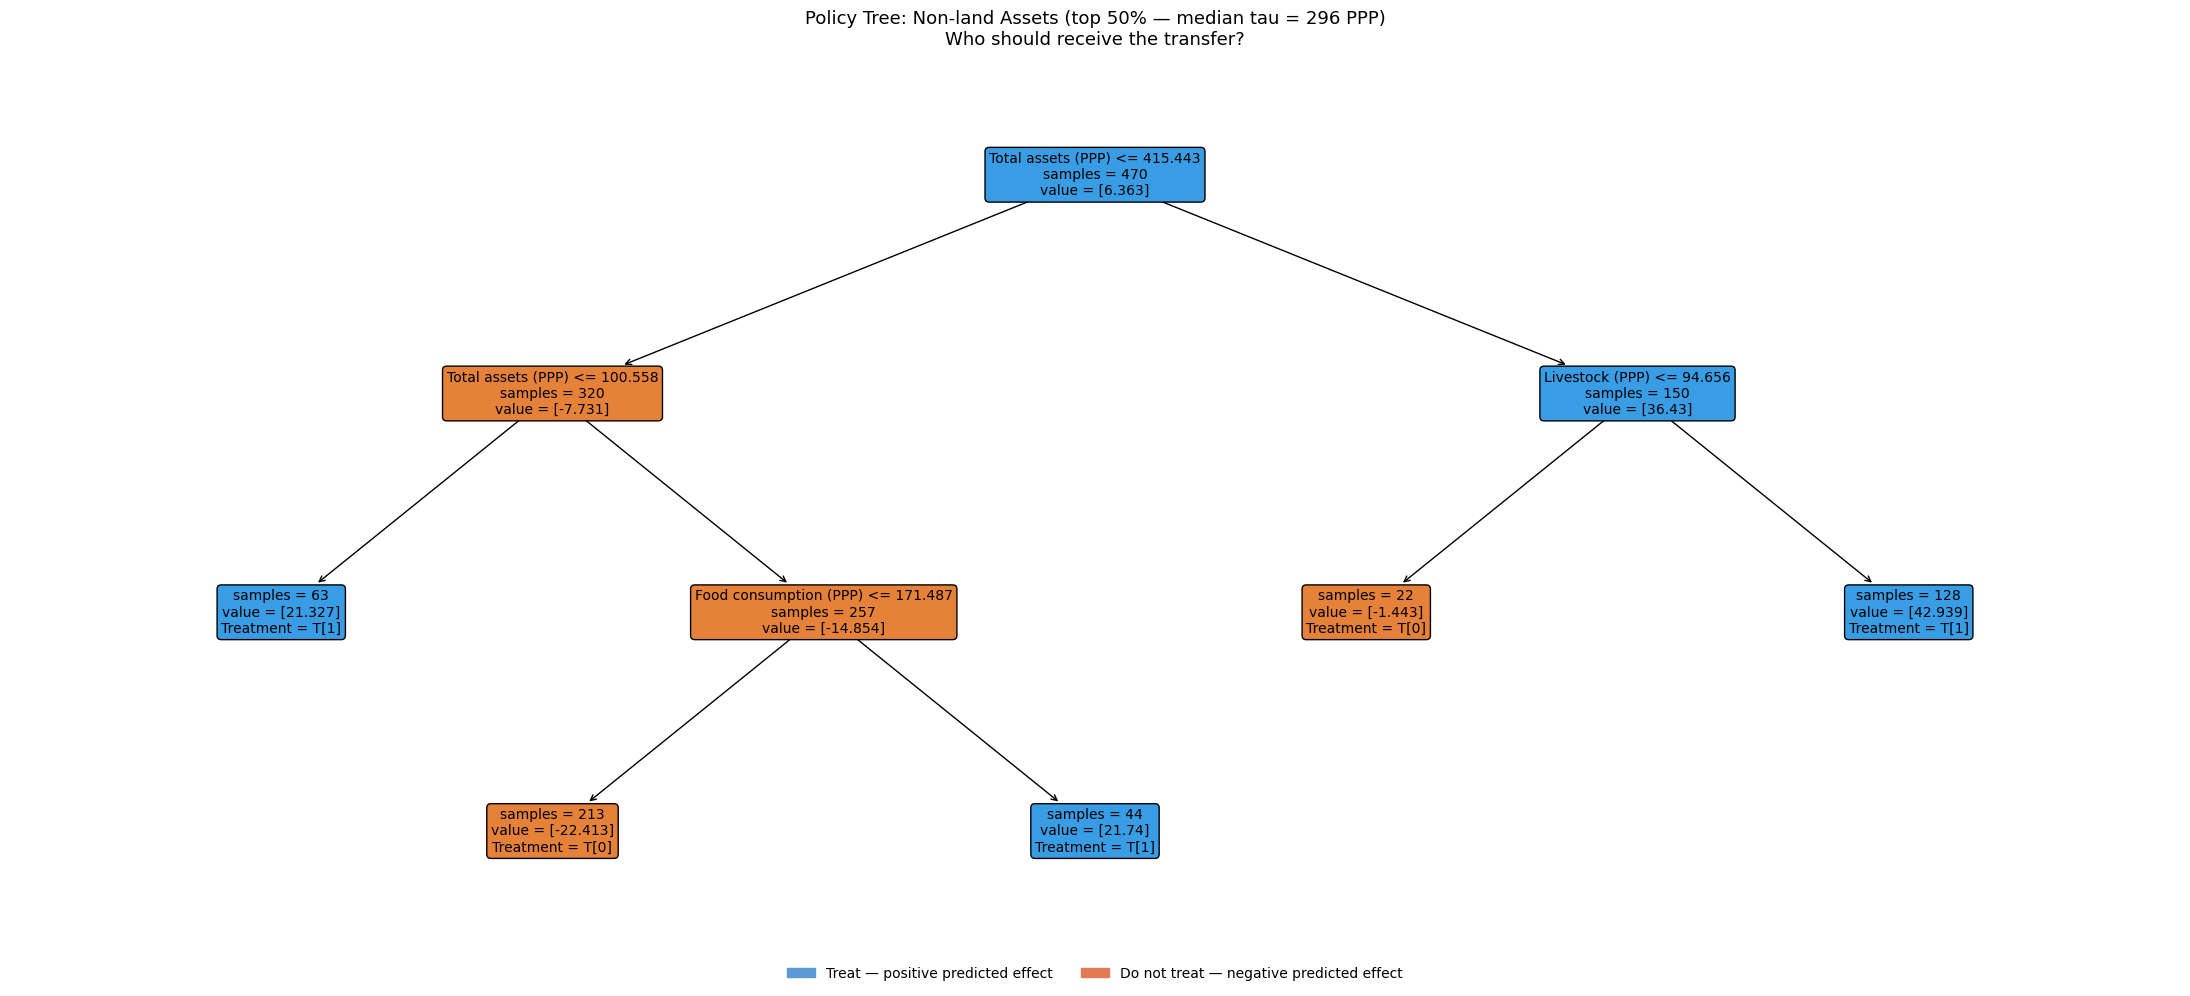


Policy Tree: Health Index (min 0.03 SD improvement)
  Leaf mean raw tau range: -0.2910 to 0.0416
  Leaves above 0.03 SD: 1 of 7
  Units with raw tau >= 0.03: 345 (36.7%)
  Households targeted:    459 (48.8%)
  Mean tau targeted:      0.0416 SD
  Mean tau untargeted:    -0.0862 SD
  Mean tau random (ATE):  -0.0238 SD
  Welfare gain vs random: 0.0654 SD per HH

  Profile of targeted (health) households:
    Age of HH head                      27.392
    Education (yrs)                     9.200
    HH size                             4.991
    Married                             0.889
    Total assets (PPP)                  268.215
    Nondurable cons. (PPP)              164.481
    Health index                        0.013
    femalerec                           0.560
    large                               0.315
    monthly                             0.560


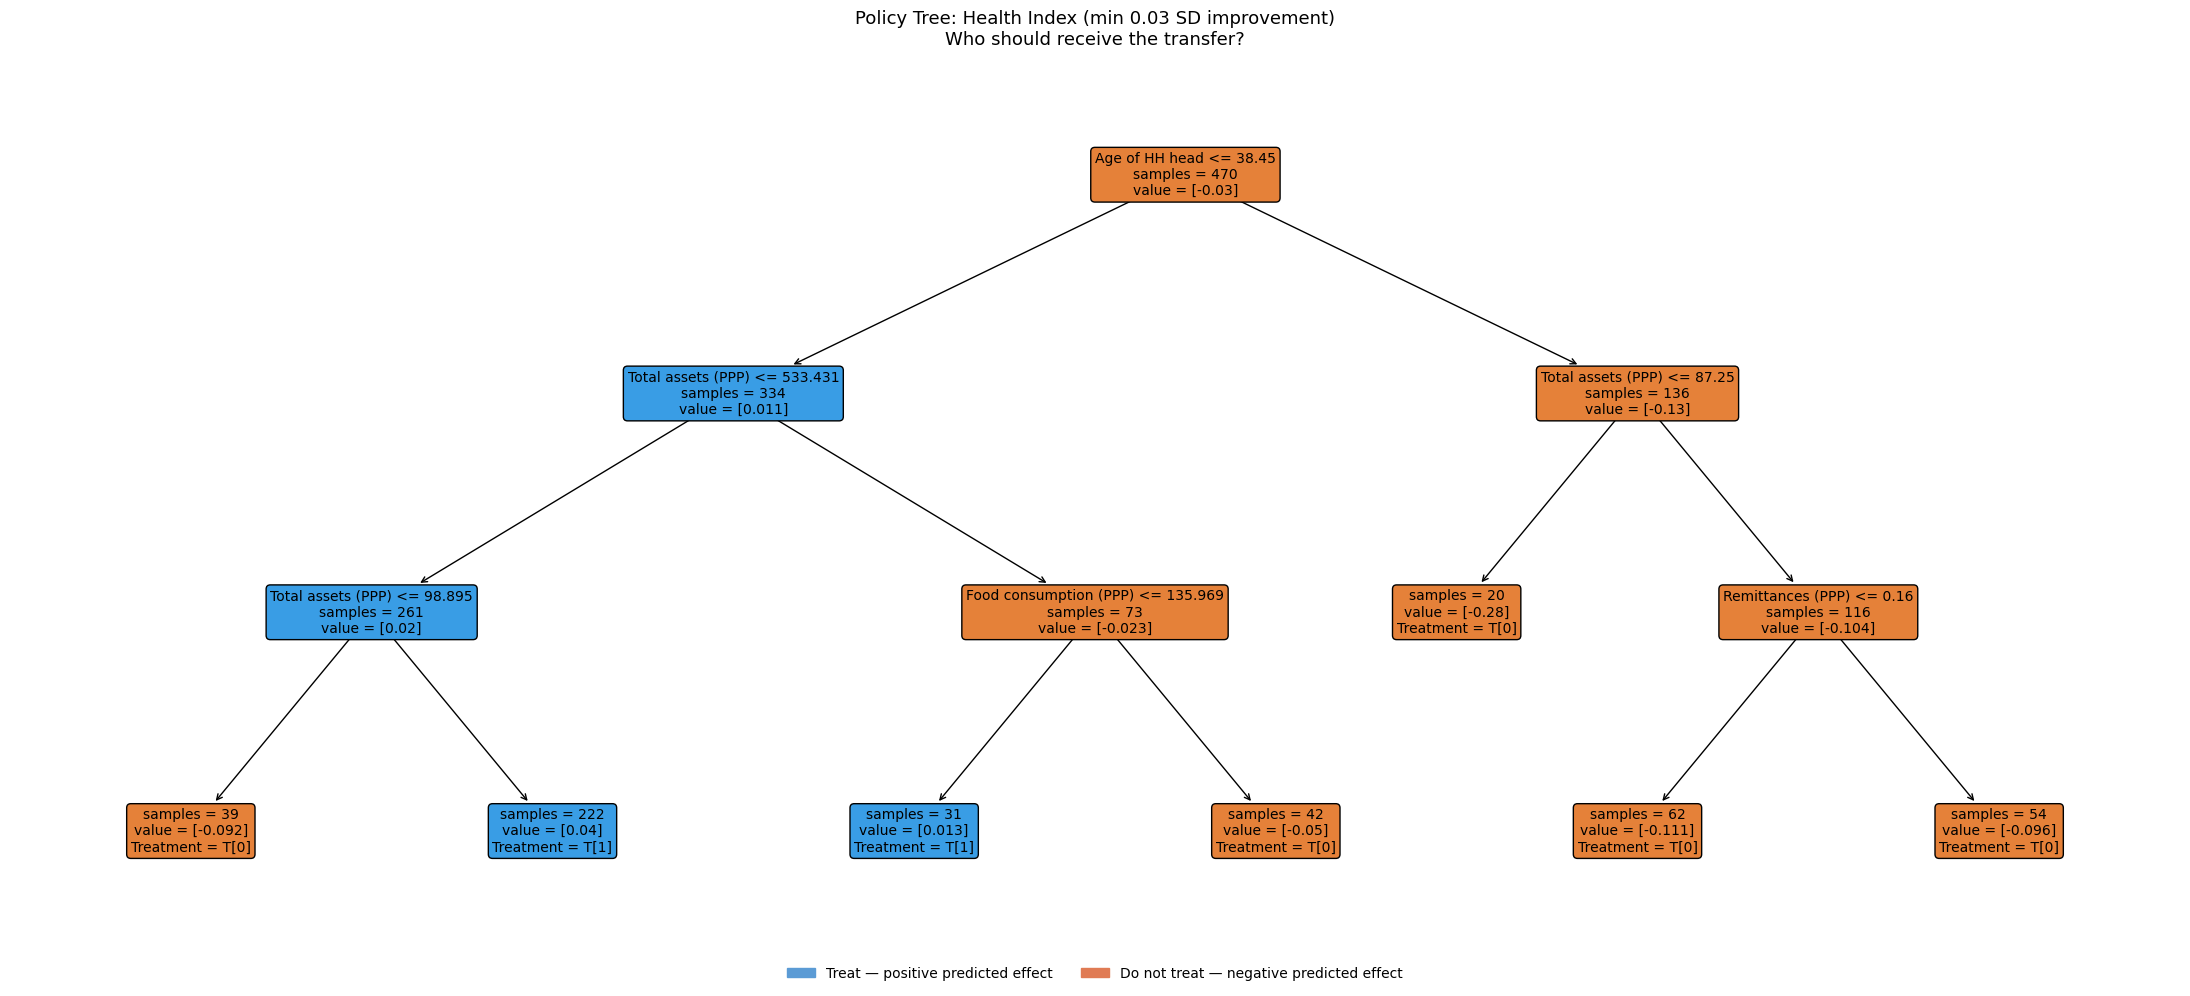


OVERLAP BETWEEN TARGETING RULES
  Assets only:   350
  Health only:   354
  Both:          105
  Neither:       131
  Overlap rate:  22.9% of health-targeted also targeted for assets


In [10]:
from econml.policy import PolicyTree
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd

# ── Clean feature names ────────────────────────────────────────
clean_names = {
    'b_age':                   'Age of HH head',
    'b_married':               'Married',
    'b_children':              'No. children',
    'b_hhsize':                'HH size',
    'b_edu':                   'Education (yrs)',
    'hh_children0':            'Children (survey)',
    'hh_totalmembers0':        'Total members',
    'asset_total_ppp0':        'Total assets (PPP)',
    'cons_nondurable_ppp0':    'Nondurable cons. (PPP)',
    'ent_total_rev_ppp0':      'Enterprise revenue (PPP)',
    'fs_hhfoodindexnew0':      'Food security index',
    'asset_livestock_ppp0':    'Livestock (PPP)',
    'asset_durable_ppp0':      'Durable assets (PPP)',
    'asset_savings_ppp0':      'Savings (PPP)',
    'asset_land_owned_total0': 'Land owned',
    'asset_niceroof0':         'Metal roof',
    'cons_allfood_ppp_m0':     'Food consumption (PPP)',
    'cons_alcohol_ppp_m0':     'Alcohol cons. (PPP)',
    'cons_tobacco_ppp_m0':     'Tobacco cons. (PPP)',
    'ent_wagelabor0':          'Wage labour',
    'ent_ownfarm0':            'Own farm',
    'ent_business0':           'Owns business',
    'fin_remittances_rec_ppp0':'Remittances (PPP)',
    'psy_index_z0':            'Psych. wellbeing',
    'med_hh_healthindex0':     'Health index',
    'ed_index0':               'Education index',
    'ih_overall_index_z0':     'Female empowerment',
    'given_mpesa':             'Has M-Pesa',
}

missing_cols = [
    'asset_total_ppp_miss0', 'cons_nondurable_ppp_miss0',
    'ent_total_rev_ppp_miss0', 'fs_hhfoodindexnew_miss0',
    'psy_index_z_miss0', 'med_hh_healthindex_miss0',
    'ed_index_miss0', 'ih_overall_index_z_miss0'
]
covariate_cols_pt      = [c for c in covariate_cols if c not in missing_cols]
feature_names_clean_pt = [clean_names.get(c, c) for c in covariate_cols_pt]

def plot_tree(pt, title, filename):
    treat_patch   = mpatches.Patch(
        color='#5B9BD5', label='Treat — positive predicted effect')
    notreat_patch = mpatches.Patch(
        color='#E07B54', label='Do not treat — negative predicted effect')
    fig, ax = plt.subplots(figsize=(22, 10))
    pt.plot(feature_names=feature_names_clean_pt, ax=ax, fontsize=10)
    ax.set_title(f'Policy Tree: {title}\nWho should receive the transfer?',
                 fontsize=13, fontweight='normal', pad=15)
    ax.legend(handles=[treat_patch, notreat_patch],
              loc='lower center', bbox_to_anchor=(0.5, -0.06),
              ncol=2, fontsize=10, frameon=False)
    plt.tight_layout()
    plt.savefig(filename, dpi=180, bbox_inches='tight')
    plt.show()

def print_profile(data_clean, mask, tau_hat, label):
    print(f"\n  Profile of {label} households:")
    targeted = data_clean[mask]
    for var in ['b_age', 'b_edu', 'b_hhsize', 'b_married',
                'asset_total_ppp0', 'cons_nondurable_ppp0',
                'med_hh_healthindex0', 'femalerec', 'large', 'monthly']:
        if var in targeted.columns:
            print(f"    {clean_names.get(var,var):<35} "
                  f"{targeted[var].mean():.3f}")

# ================================================================
# TREE 1: Non-land Assets
# Centred reward forces 50/50 split — node values are relative
# to median tau but targeting is correct
# ================================================================
res_a        = cf_results['asset_total_ppp1']
data_clean_a = res_a['data_clean']
tau_hat_a    = res_a['tau_hat']
X_pt_a       = data_clean_a[covariate_cols_pt].fillna(0).values

tau_median_a  = np.median(tau_hat_a)
tau_centred_a = tau_hat_a - tau_median_a
reward_a      = np.column_stack([np.zeros(len(tau_hat_a)), tau_centred_a])

pt_assets = PolicyTree(max_depth=3, min_samples_leaf=20, random_state=42)
pt_assets.fit(X_pt_a, reward_a)
mask_assets = pt_assets.predict(X_pt_a) == 1

print(f"\n{'='*60}")
print(f"Policy Tree: Non-land Assets (top 50% budget)")
print(f"  Note: node values show tau relative to median ({tau_median_a:.0f} PPP)")
print(f"{'='*60}")
print(f"  Households targeted:    {mask_assets.sum()} ({mask_assets.mean():.1%})")
print(f"  Mean tau targeted:      {tau_hat_a[mask_assets].mean():.2f} PPP")
print(f"  Mean tau untargeted:    {tau_hat_a[~mask_assets].mean():.2f} PPP")
print(f"  Mean tau random (ATE):  {tau_hat_a.mean():.2f} PPP")
print(f"  Welfare gain vs random: "
      f"{tau_hat_a[mask_assets].mean() - tau_hat_a.mean():.2f} PPP per HH")
print_profile(data_clean_a, mask_assets, tau_hat_a, 'targeted (assets)')

plot_tree(pt_assets,
          f'Non-land Assets (top 50% — median tau = {tau_median_a:.0f} PPP)',
          'policy_tree_assets.png')

# ================================================================
# TREE 2: Health Index — min 0.03 SD improvement
# Key fix: fit on raw tau_hat, then compute ACTUAL mean raw tau
# per leaf and apply 0.03 threshold to that — not to reward value
# ================================================================
res_h        = cf_results['med_hh_healthindex1']
data_clean_h = res_h['data_clean']
tau_hat_h    = res_h['tau_hat']
X_pt_h       = data_clean_h[covariate_cols_pt].fillna(0).values

MIN_EFFECT = 0.03

# Fit on raw tau — health spans negative to positive
# so tree naturally discriminates
reward_h = np.column_stack([np.zeros(len(tau_hat_h)), tau_hat_h])

pt_health = PolicyTree(max_depth=3, min_samples_leaf=20, random_state=42)
pt_health.fit(X_pt_h, reward_h)

# Get leaf assignment for each unit using apply()
leaf_ids = pt_health.apply(X_pt_h)

# Compute mean RAW tau per leaf
leaf_mean_tau = {}
for leaf_id in np.unique(leaf_ids):
    leaf_mask = leaf_ids == leaf_id
    leaf_mean_tau[leaf_id] = tau_hat_h[leaf_mask].mean()

# Each unit's leaf mean raw tau
unit_leaf_tau = np.array([leaf_mean_tau[lid] for lid in leaf_ids])

# Mask: tree says treat AND leaf mean raw tau >= MIN_EFFECT
tree_says_treat = pt_health.predict(X_pt_h) == 1
mask_health     = tree_says_treat & (unit_leaf_tau >= MIN_EFFECT)

print(f"\n{'='*60}")
print(f"Policy Tree: Health Index (min {MIN_EFFECT} SD improvement)")
print(f"{'='*60}")
print(f"  Leaf mean raw tau range: "
      f"{min(leaf_mean_tau.values()):.4f} to {max(leaf_mean_tau.values()):.4f}")
print(f"  Leaves above {MIN_EFFECT} SD: "
      f"{sum(v >= MIN_EFFECT for v in leaf_mean_tau.values())} "
      f"of {len(leaf_mean_tau)}")
print(f"  Units with raw tau >= {MIN_EFFECT}: "
      f"{(tau_hat_h >= MIN_EFFECT).sum()} ({(tau_hat_h >= MIN_EFFECT).mean():.1%})")
print(f"  Households targeted:    {mask_health.sum()} ({mask_health.mean():.1%})")
if mask_health.sum() > 0:
    print(f"  Mean tau targeted:      {tau_hat_h[mask_health].mean():.4f} SD")
    print(f"  Mean tau untargeted:    {tau_hat_h[~mask_health].mean():.4f} SD")
    print(f"  Mean tau random (ATE):  {tau_hat_h.mean():.4f} SD")
    print(f"  Welfare gain vs random: "
          f"{tau_hat_h[mask_health].mean() - tau_hat_h.mean():.4f} SD per HH")
    print_profile(data_clean_h, mask_health, tau_hat_h, 'targeted (health)')
else:
    print("  No leaves meet the 0.03 SD threshold — try lowering MIN_EFFECT")

plot_tree(pt_health,
          f'Health Index (min {MIN_EFFECT} SD improvement)',
          'policy_tree_health.png')

# ================================================================
# Overlap
# ================================================================
print(f"\n{'='*60}")
print("OVERLAP BETWEEN TARGETING RULES")
print(f"{'='*60}")
both    = mask_assets & mask_health
neither = ~mask_assets & ~mask_health
print(f"  Assets only:   {(mask_assets & ~mask_health).sum()}")
print(f"  Health only:   {(mask_health & ~mask_assets).sum()}")
print(f"  Both:          {both.sum()}")
print(f"  Neither:       {neither.sum()}")
if mask_health.sum() > 0:
    print(f"  Overlap rate:  {both.sum()/mask_health.sum():.1%} "
          f"of health-targeted also targeted for assets")